In [1]:
#pip install git+https://github.com/cellgeni/cloupe.git

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
#from cloupe import Cloupe

In [3]:
# Load your cloupe file
#preterm = Cloupe("../data/wang-et-al-2024/GSM8063093_PTB.cloupe", load_csr=True)
#term = Cloupe("../data/wang-et-al-2024/GSM8063094_Term.cloupe", load_csr=True)

# Convert directly to AnnData format (h5ad)
#preterm.to_anndata()
#term.to_anndata()

In [4]:
preterm = sc.read_h5ad("../data/wang-et-al-2024/GSM8063093_PTB.h5ad")
term = sc.read_h5ad("../data/wang-et-al-2024/GSM8063094_Term.h5ad")

In [5]:
preterm

AnnData object with n_obs × n_vars = 1939 × 36603
    var: 'FeatureNames'
    obsm: 'UMAP', 'tsne'

In [6]:
term

AnnData object with n_obs × n_vars = 45217 × 36603
    var: 'FeatureNames'
    obsm: 'UMAP', 'tsne'

# Add metadata

In [7]:
# Author
preterm.obs['author'] = 'wang-et-al-2024'
term.obs['author'] = 'wang-et-al-2024'

# DOI
preterm.obs['doi'] = '10.1055/a-2491-4391'
term.obs['doi'] = '10.1055/a-2491-4391'

In [8]:
# Gestational age in weeks
preterm.obs['gestational_age'] = 35
term.obs['gestational_age'] = 38

# Birth type
preterm.obs['birth'] = 'preterm'
term.obs['birth'] = 'term'

# Tissue type
preterm.obs['tissue'] = 'placenta'
term.obs['tissue'] = 'placenta'

# Cell type
preterm.obs['cell_type'] = 'primary-villous-cytotrophoblast'
term.obs['cell_type'] = 'primary-villous-cytotrophoblast'

# Quality control

In [9]:
preterm.var["mt"] = preterm.var_names.str.startswith("MT-")
preterm.var["ribo"] = preterm.var_names.str.startswith(("RPS", "RPL"))
preterm.var["hb"] = preterm.var_names.str.startswith("^HB[^(P)]")

term.var["mt"] = term.var_names.str.startswith("MT-")
term.var["ribo"] = term.var_names.str.startswith(("RPS", "RPL"))
term.var["hb"] = term.var_names.str.startswith("^HB[^(P)]")

In [10]:
sc.pp.calculate_qc_metrics(
    preterm, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

sc.pp.calculate_qc_metrics(
    term, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

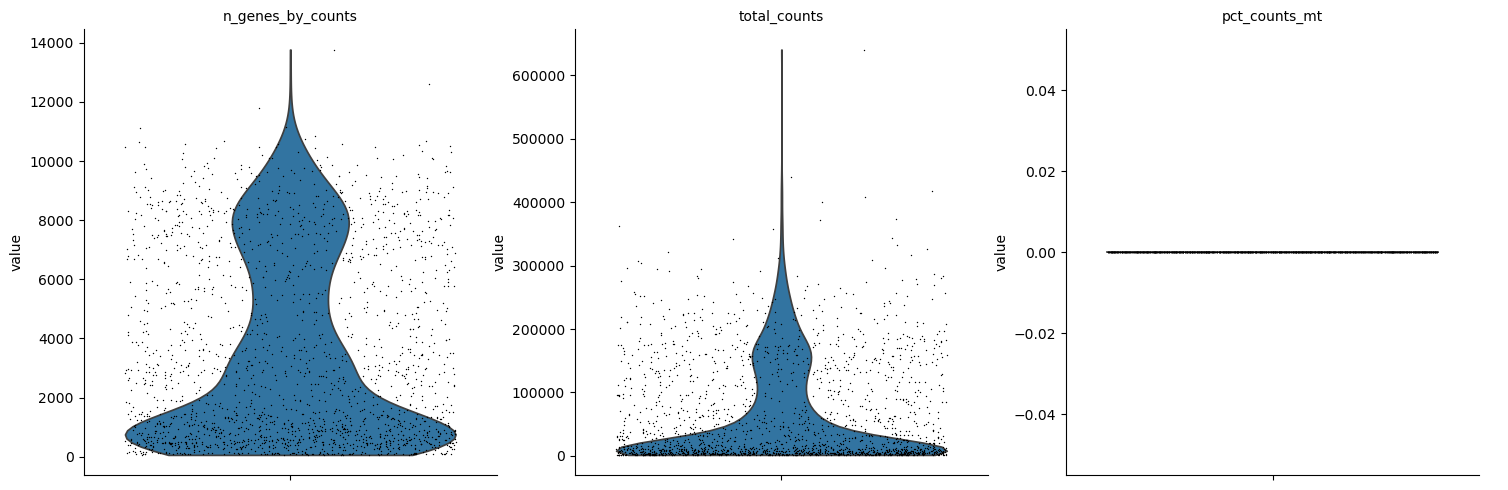

In [11]:
sc.pl.violin(
    preterm,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

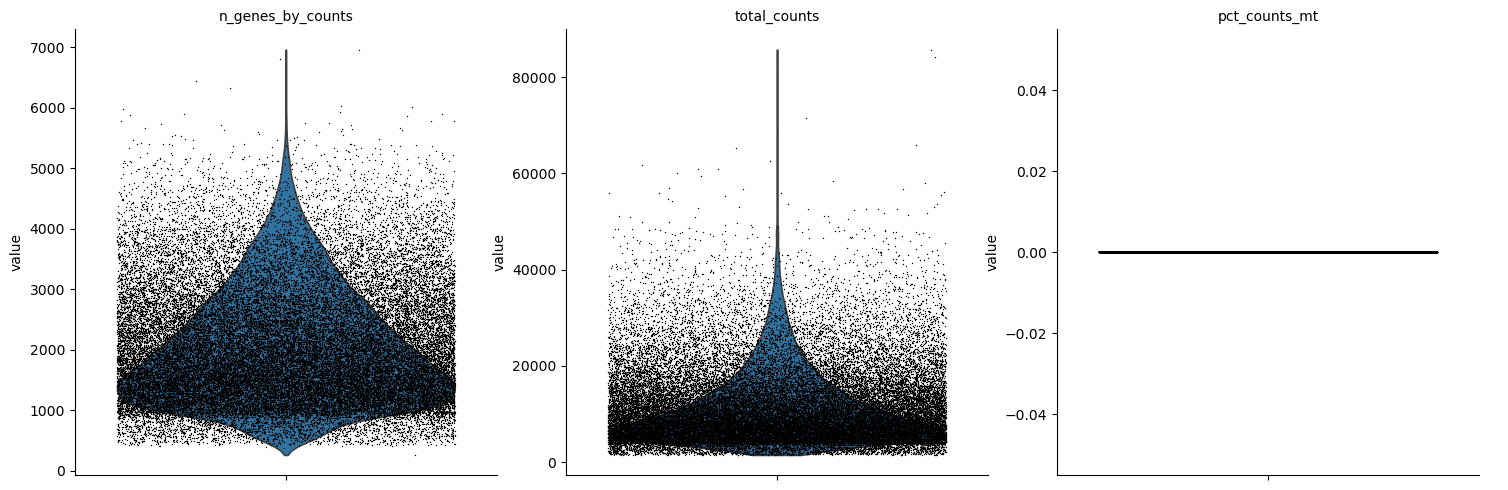

In [12]:
sc.pl.violin(
    term,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

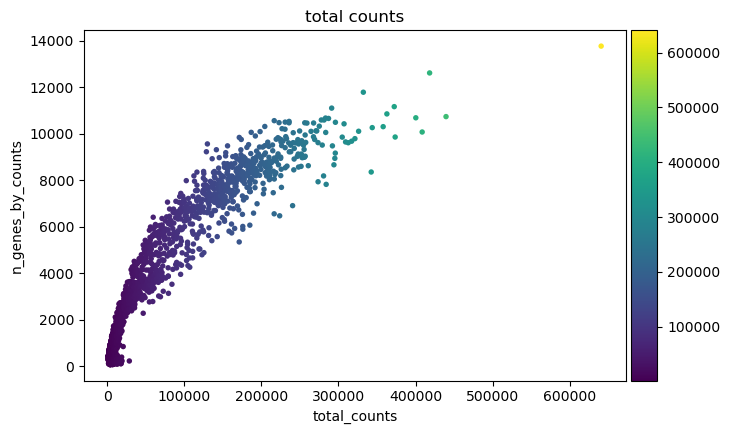

In [13]:
sc.pl.scatter(preterm, "total_counts", "n_genes_by_counts", color="total_counts")

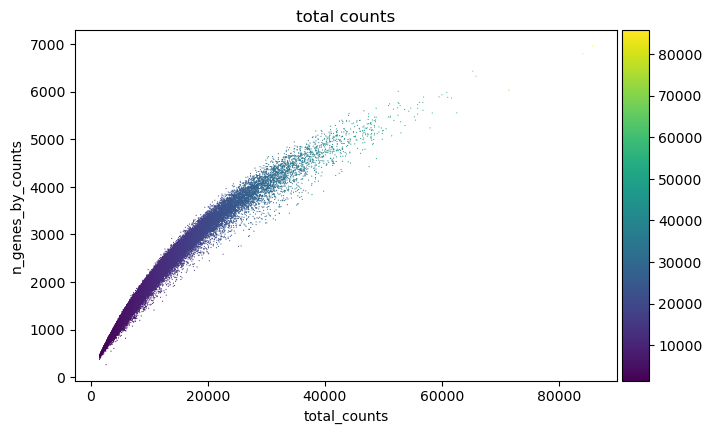

In [14]:
sc.pl.scatter(term, "total_counts", "n_genes_by_counts", color="total_counts")

In [15]:
# Filter out cells with >20% mitochondrial content
preterm = preterm[preterm.obs.pct_counts_mt <= 20, :]
term = term[term.obs.pct_counts_mt <= 20, :]

In [16]:
sc.pp.filter_cells(preterm, min_genes=100)
sc.pp.filter_genes(preterm, min_cells=3)

sc.pp.filter_cells(term, min_genes=100)
sc.pp.filter_genes(term, min_cells=3)

/home/dora/miniconda3/envs/RP1/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
/home/dora/miniconda3/envs/RP1/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


Are there any negative values present in the datasets? If there are, they should be removed at this step to avoid errors downstream.

In [17]:
total_counts = np.array(preterm.X.sum(axis=1)).flatten()
print(f"Cells with total count 0: {(total_counts == 0).sum()}")

Cells with total count 0: 0


In [18]:
total_counts = np.array(term.X.sum(axis=1)).flatten()
print(f"Cells with total count 0: {(total_counts == 0).sum()}")

Cells with total count 0: 0


# Normalization

In [19]:
# Saving count data
preterm.layers["counts"] = preterm.X.copy()
term.layers["counts"] = term.X.copy()

In [20]:
# Convert to array before normalization
preterm.X = preterm.X.toarray()
term.X = term.X.toarray()

It is more memory efficient to avoid the above step and keep the expression data as a sparse matrix rather than a dense matrix stored in an array. In case of memory issues in the downstream analysis, try skipping the above step.

In [21]:
# Normalizing to median total counts
sc.pp.normalize_total(preterm)
sc.pp.normalize_total(term)

# Logarithmize the data
sc.pp.log1p(preterm)
sc.pp.log1p(term)

# Feature selection

In [22]:
sc.pp.highly_variable_genes(preterm, n_top_genes=2000)
sc.pp.highly_variable_genes(term, n_top_genes=2000)

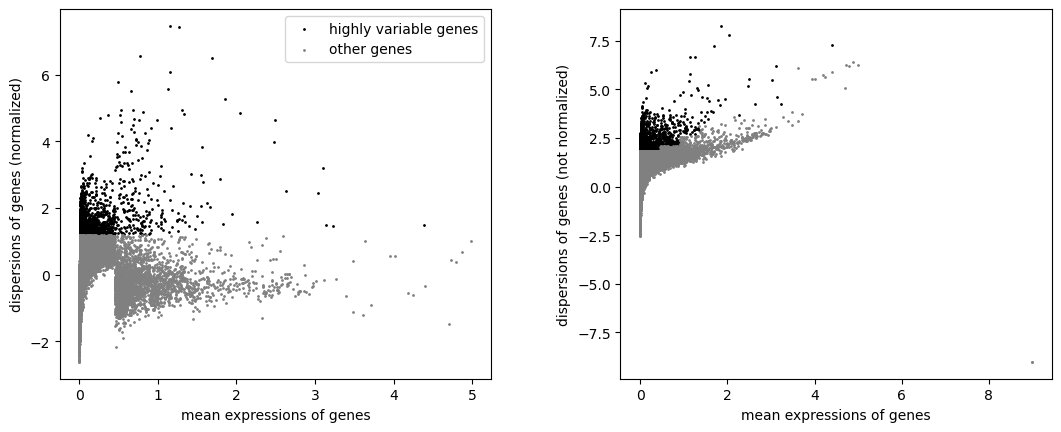

In [23]:
sc.pl.highly_variable_genes(preterm)

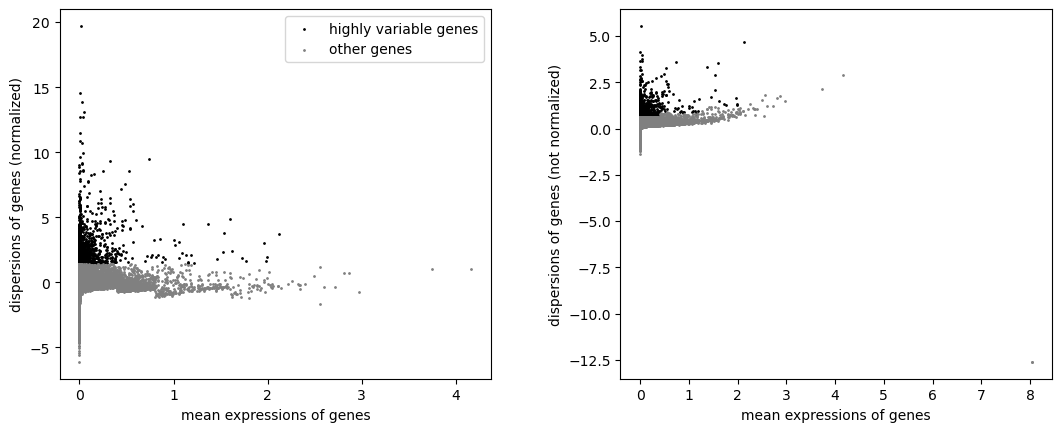

In [24]:
sc.pl.highly_variable_genes(term)

# Dimensionality reduction

In [25]:
sc.tl.pca(preterm)
sc.tl.pca(term)

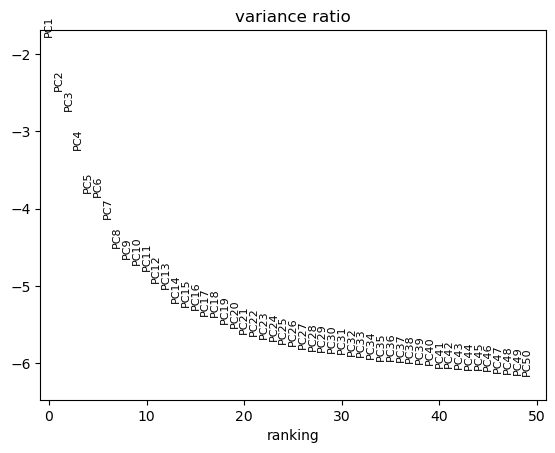

In [26]:
sc.pl.pca_variance_ratio(preterm, n_pcs=50, log=True)

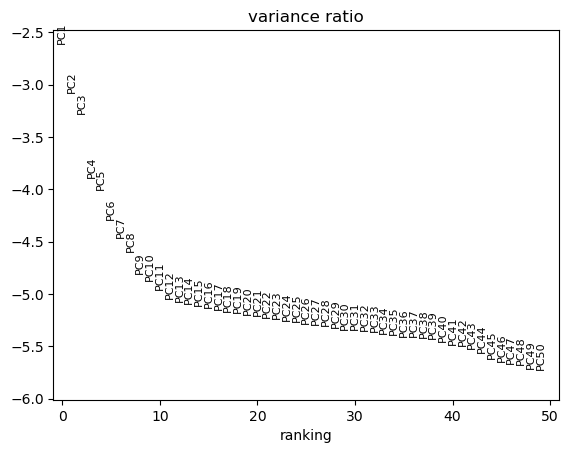

In [27]:
sc.pl.pca_variance_ratio(term, n_pcs=50, log=True)

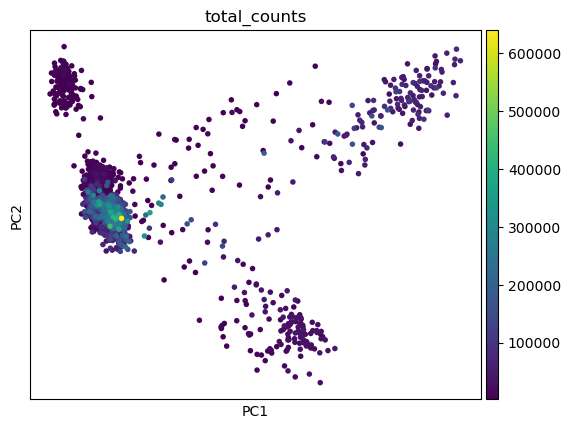

In [28]:
sc.pl.pca(preterm, color = "total_counts")

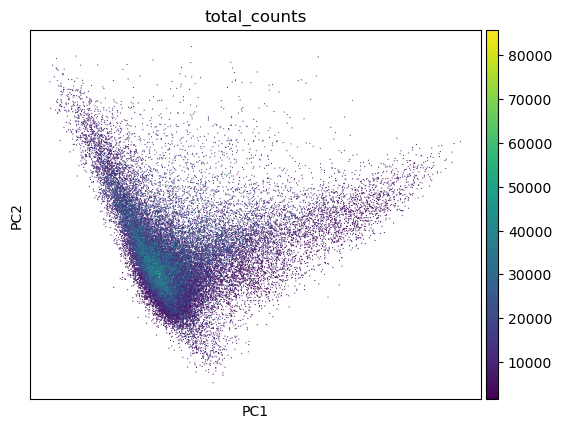

In [29]:
sc.pl.pca(term, color = "total_counts")

# Nearest neighbour graph construction and visualization

In [30]:
sc.pp.neighbors(preterm)
sc.pp.neighbors(term)

In [31]:
sc.tl.umap(preterm)
sc.tl.umap(term)

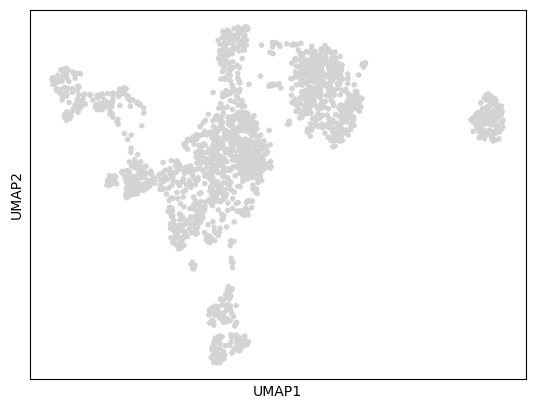

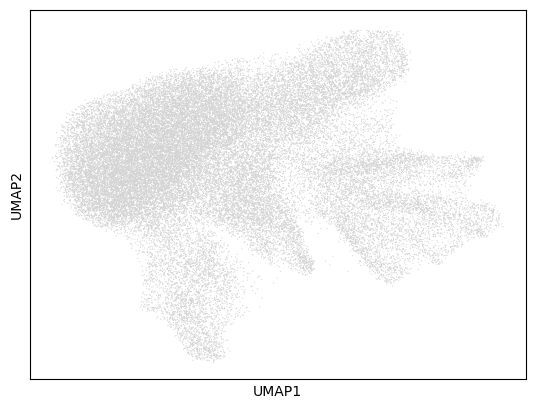

In [32]:
sc.pl.umap(preterm)
sc.pl.umap(term)

# Clustering

Adjust the below resolution number to get the exact number of leiden clusters present in CLOUPE data visualised in the Loupe Browser (20 for term and 9 for preterm data). Ideally, match the clusters using DGE later on.

In [33]:
sc.tl.leiden(preterm, flavor = "igraph", n_iterations = 3, resolution = 0.4)

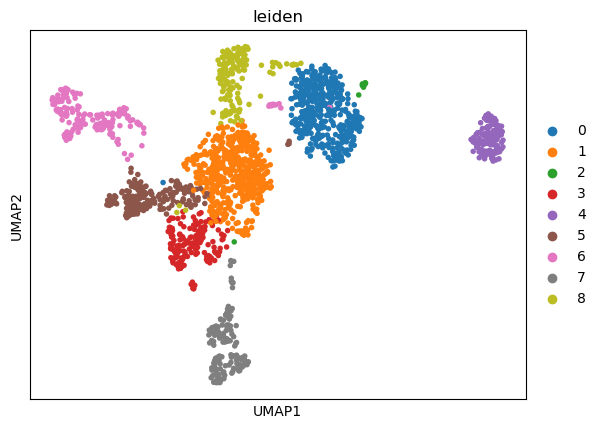

In [48]:
sc.pl.umap(preterm, color = "leiden", save = "preterm.svg")

In [35]:
sc.tl.leiden(term, flavor = "igraph", n_iterations = 3, resolution = 1.76)

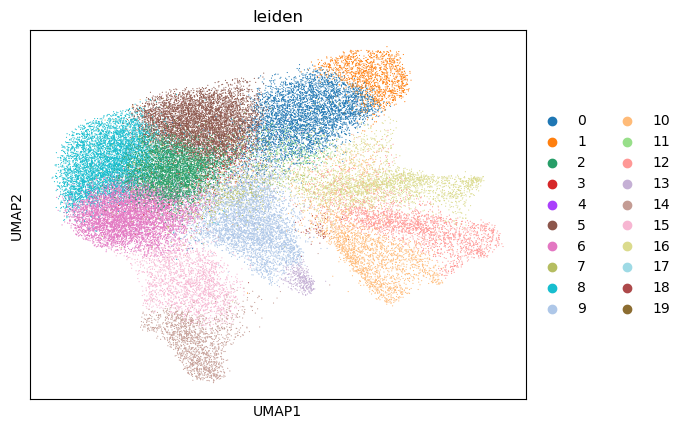

In [49]:
sc.pl.umap(term, color = "leiden", save = "term.svg")

In [37]:
# Reassess quality control and cell filtering

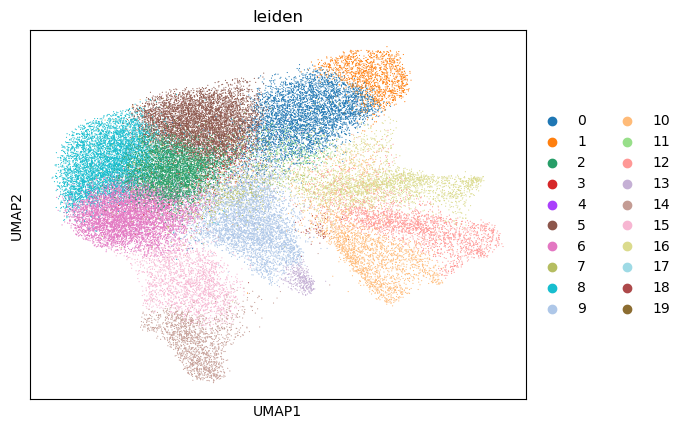

In [38]:
sc.pl.umap(
    term,
    color="leiden",
    # increase horizontal space between panels
    wspace=0.5,
    #size=3,
)

# Differentially expressed genes as markers

In [39]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(term, groupby="leiden", method="wilcoxon")

In [40]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(preterm, groupby="leiden", method="wilcoxon")

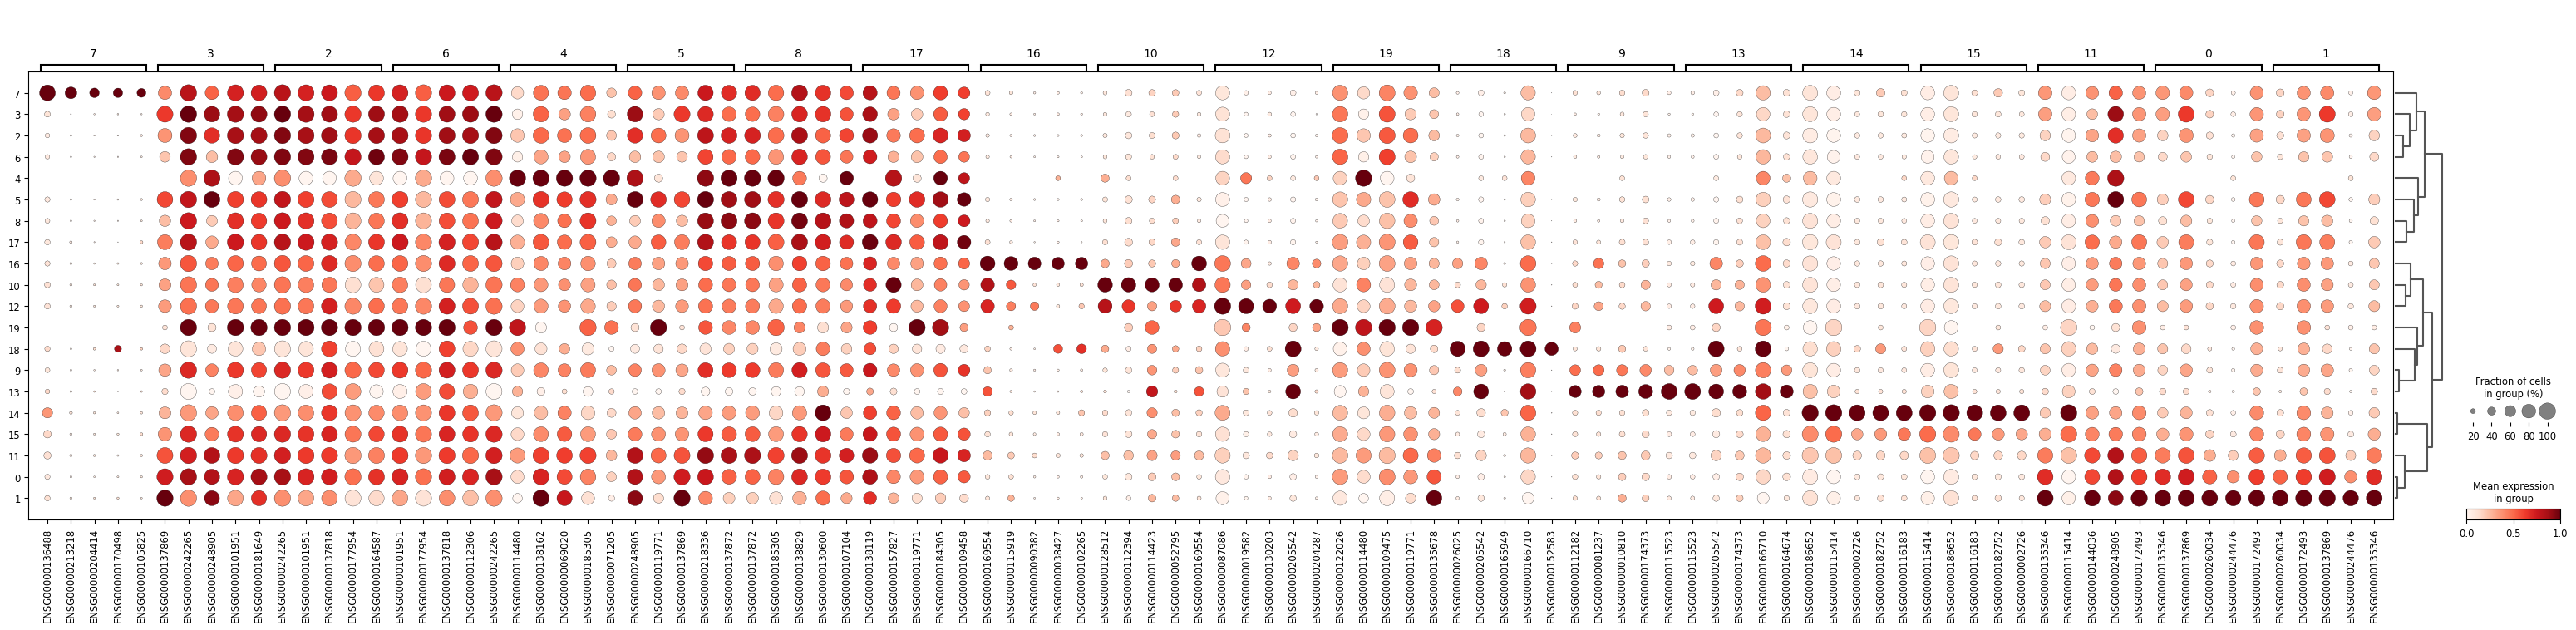

In [50]:
sc.pl.rank_genes_groups_dotplot(
    term, groupby="leiden", standard_scale="var", n_genes=5, save = "term.svg"
)

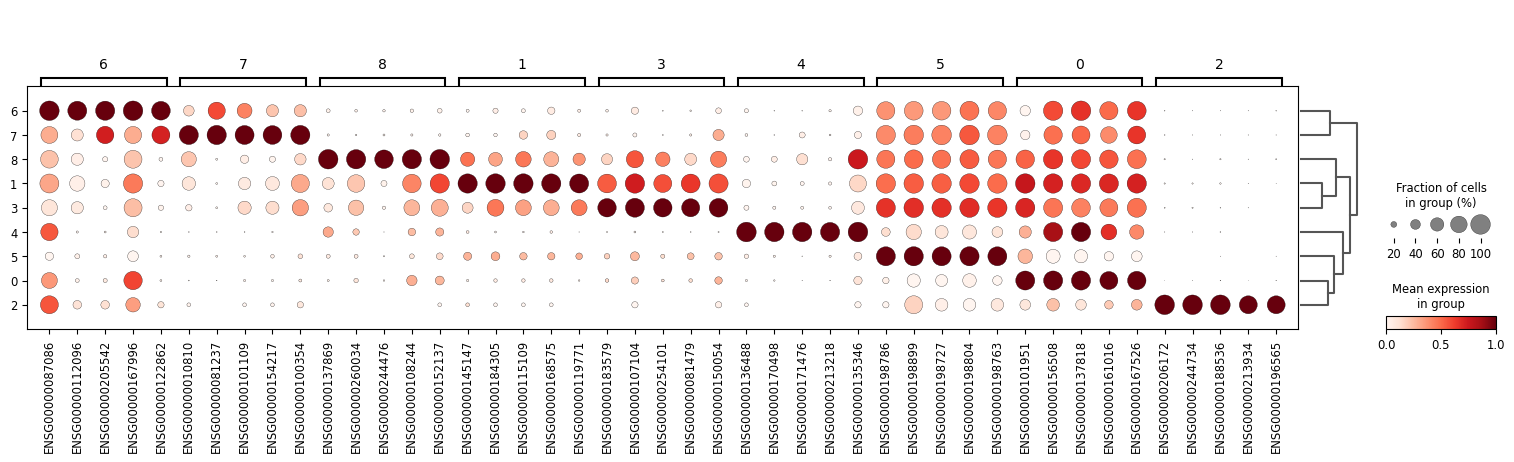

In [51]:
sc.pl.rank_genes_groups_dotplot(
    preterm, groupby="leiden", standard_scale="var", n_genes=5, save = "preterm.svg"
)

In [53]:
preterm_df_0 = sc.get.rank_genes_groups_df(preterm, group="0")
preterm_df_0.to_csv("preterm_DEGs_0.csv", index=False)

In [54]:
preterm_df_1 = sc.get.rank_genes_groups_df(preterm, group="1")
preterm_df_1.to_csv("preterm_DEGs_1.csv", index=False)

In [55]:
preterm_df_2 = sc.get.rank_genes_groups_df(preterm, group="2")
preterm_df_2.to_csv("preterm_DEGs_2.csv", index=False)

In [56]:
preterm_df_3 = sc.get.rank_genes_groups_df(preterm, group="3")
preterm_df_3.to_csv("preterm_DEGs_3.csv", index=False)

In [57]:
preterm_df_4 = sc.get.rank_genes_groups_df(preterm, group="4")
preterm_df_4.to_csv("preterm_DEGs_4.csv", index=False)

In [58]:
preterm_df_5 = sc.get.rank_genes_groups_df(preterm, group="5")
preterm_df_5.to_csv("preterm_DEGs_5.csv", index=False)

In [59]:
preterm_df_6 = sc.get.rank_genes_groups_df(preterm, group="6")
preterm_df_6.to_csv("preterm_DEGs_6.csv", index=False)

In [60]:
preterm_df_7 = sc.get.rank_genes_groups_df(preterm, group="7")
preterm_df_7.to_csv("preterm_DEGs_7.csv", index=False)

In [61]:
preterm_df_8 = sc.get.rank_genes_groups_df(preterm, group="8")
preterm_df_8.to_csv("preterm_DEGs_8.csv", index=False)

In [46]:
sc.get.rank_genes_groups_df(term, group="4").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000114480,3.636793,2.703262,0.000276,0.999795
1,ENSG00000138162,3.293257,1.875454,0.000990,0.999795
2,ENSG00000069020,3.208662,2.015787,0.001334,0.999795
3,ENSG00000185305,3.202460,1.556461,0.001363,0.999795
4,ENSG00000071205,3.152488,2.249292,0.001619,0.999795
